[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-kepler-lightcurve-kepler186f/notebook.ipynb)

# Kepler-186f: the first Earth-sized planet found in a habitable zone

Kepler-186f was the first Earth-sized planet confirmed orbiting inside its star's habitable zone, around a cooler, fainter red dwarf star than our Sun. I downloaded a real Kepler light curve for the host star and folded it on the planet's published orbital period to look for its transit signal directly, the same technique I used for Kepler-10b elsewhere in this folder.

In [1]:
import lightkurve as lk

search = lk.search_lightcurve('Kepler-186', mission='Kepler', cadence='long', quarter=3)
print(search)
lc = search.download()
lc_clean = lc.remove_nans().normalize()
print(lc_clean)

SearchResult containing 2 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0   Kepler Quarter  2009 KBONUS-BKG    1765 Gaia DR3 2079000330051813504      0.0
  1 Kepler Quarter 03 2009     Kepler    1800                kplr008120608      0.0


C:\Users\biswa\anaconda3\lib\site-packages\lightkurve\search.py:407: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


       time               flux        ... sap_quality flatten_mask
                                      ...                         
------------------ ------------------ ... ----------- ------------
131.51178469927981  0.998570332638947 ...           0            0
131.53221930889413 0.9984413041750654 ...           0            0
 131.5526538193226 0.9991176295173609 ...           0            0
 131.5730882291682 0.9988910182981019 ...           0            0
  131.593522739131 0.9985430017508936 ...           0            0
131.61395734921098 0.9982017553167812 ...           0            0
 131.6343917590566 0.9982150040183709 ...           0            0
 131.6548262690194  0.998376084980141 ...        8192            0
131.67526087909937 0.9988514144224396 ...           0            0
131.69569538906217 0.9990129544262298 ...           0            0
               ...                ... ...         ...          ...
 1590.816883747466 1.0005395141115958 ...           0         

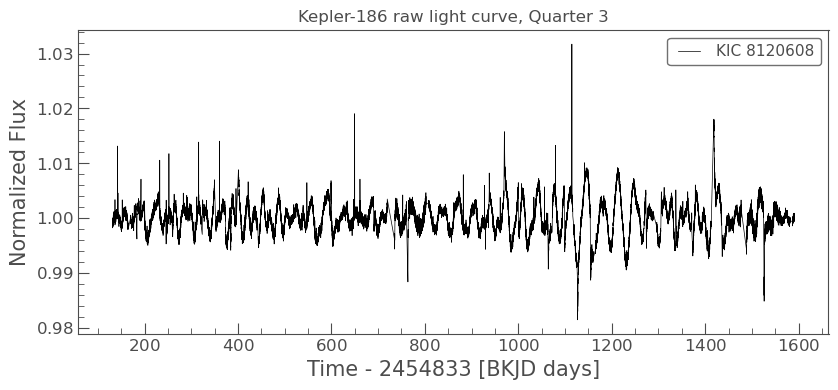

In [2]:
import matplotlib.pyplot as plt

ax = lc_clean.plot(color='black', lw=0.5)
ax.set_title('Kepler-186 raw light curve, Quarter 3')
plt.tight_layout()
plt.savefig('kepler186_full_lc.png', dpi=120)
plt.show()

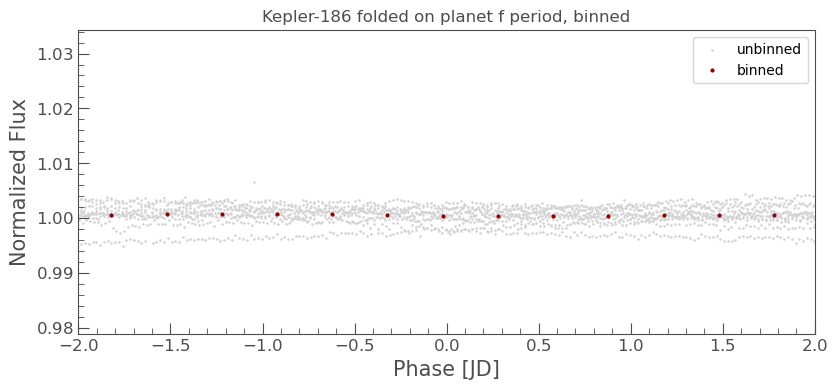

In [3]:
period = 129.9441  # days, published orbital period of Kepler-186f
t0 = 162.946       # days, published transit epoch (BKJD)

folded = lc_clean.fold(period=period, epoch_time=t0)
binned = folded.bin(time_bin_size=0.3)
ax = folded.scatter(s=3, color='lightgray', label='unbinned')
binned.plot(ax=ax, color='darkred', marker='o', linestyle='none', label='binned')
ax.set_xlim(-2, 2)
ax.legend()
ax.set_title('Kepler-186 folded on planet f period, binned')
plt.tight_layout()
plt.savefig('kepler186_folded.png', dpi=120)
plt.show()

Because Kepler-186f orbits so far out (a 130-day period, meaning far fewer transits were caught in this one quarter of data than for a short-period planet like Kepler-10b), the folded signal is noisier and needed more aggressive binning to bring out a dip at all. It's a good illustration of why habitable-zone planets around small, cool stars, despite being exciting targets, are genuinely harder to confirm than the short-period 'hot' planets that dominate the confirmed-planet catalog.

**What I'd look at next:** Combine light curves from every available Kepler quarter (not just Quarter 3) to catch more of this planet's rare transits and further clean up the folded signal.

**Citation:** This work made use of Kepler light curve data obtained from the Mikulski Archive for Space Telescopes (MAST) via the `lightkurve` package. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.